In [14]:
import pandas as pd

In [15]:
train_df = pd.read_parquet('../data/processed/train_split_no_fss.parquet')
test_df = pd.read_parquet('../data/processed/test_split_no_fss.parquet')

In [16]:
X_train = train_df["Consumer complaint narrative"]
y_train = train_df["Product"]

In [17]:
X_test = test_df["Consumer complaint narrative"]
y_test = test_df["Product"]

In [18]:
import re

def remove_mask_tokens(text):
    return re.sub(r"\bx+\b", " ", text.lower())

X_train = train_df["Consumer complaint narrative"].apply(remove_mask_tokens)

Untuned SVM

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9
    )),
    ("classifier", LinearSVC(
        C=1.0,
        class_weight=None,
        random_state=42
    ))
])

In [20]:
# train
svm_pipeline.fit(X_train, y_train)

# predict
y_pred = svm_pipeline.predict(X_test)

In [21]:
from sklearn.metrics import classification_report, f1_score

y_pred = svm_pipeline.predict(X_test)

print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred))

Macro F1: 0.7884759279271276
                                      precision    recall  f1-score   support

                       Bank Accounts       0.80      0.83      0.82     13761
                      Consumer Loans       0.67      0.41      0.51      3195
                    Credit Reporting       0.95      0.97      0.96    188824
             Credit or Prepaid Cards       0.80      0.78      0.79     17297
                     Debt collection       0.81      0.76      0.79     30468
Money Transfers and Digital Payments       0.86      0.81      0.83      8503
                            Mortgage       0.90      0.91      0.91     10518
                        Student loan       0.88      0.81      0.84      4455
               Vehicle loan or lease       0.70      0.62      0.66      3592

                            accuracy                           0.91    280613
                           macro avg       0.82      0.77      0.79    280613
                        weighted 

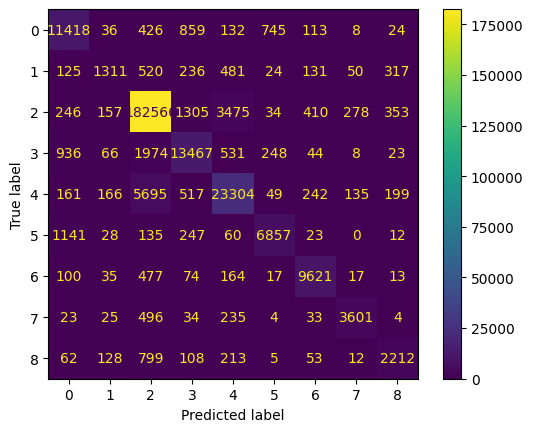

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# predictions
y_pred = svm_pipeline.predict(X_test)

# compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()